In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np

# Setting up the model

Partial Differential Equation (PDE) tracks variation in both time and space.

In [2]:
model = pybamm.BaseModel()

In [3]:
# for solving a PDE, we need to define a variable , and create a domain each variable belongs to
c = pybamm.Variable("Concentration", domain="negative particle")        #Note that we have given our variable the (useful) name “Concentration”, but the symbol representing this variable is simply c.

In [4]:
N = -pybamm.grad(c)  # define the flux: spacial gradient of c (N = -dc/dx)
dcdt = -pybamm.div(N)  # spatial divergence of N (dcdt = -dN/dx)

model.rhs = {c: dcdt}  # add the equation to rhs dictionary dcdt = -d2c/dx2

In [5]:
# Unlike ODE models, PDE models require both initial and boundary conditions.
# initial conditions
model.initial_conditions = {c: pybamm.Scalar(1)}        # at t = 0, c = 1

# boundary conditions
# "Dirichlet" fixes the value of the variable at the boundary, while "Neumann" fixes the spatial gradient at the boundary.
lbc = pybamm.Scalar(0)      # left boundary condition: dc/dx = 0 at x = 0
rbc = pybamm.Scalar(2)      # right boundary condition: dc/dx = 2 at x = 1
model.boundary_conditions = {c: {"left": (lbc, "Neumann"), "right": (rbc, "Neumann")}}

In [6]:
# add variables of interest to the dictionary
model.variables = {"Concentration": c, "Flux": N}

# Using the model

## Defining a geometry and mesh

In [7]:
# define geometry r
r = pybamm.SpatialVariable(
    "r", domain=["negative particle"], coord_sys="spherical polar"
)

# 0 <= r <= 1
geometry = {
    "negative particle": {r: {"min": pybamm.Scalar(0), "max": pybamm.Scalar(1)}}
}

# the left key "lbc" is conventionally coupled with "min" geometry, and right key is "max" geometry side

In [8]:
# mesh and discretize: create a uniform one-dimensional mesh with 20 points
submesh_types = {"negative particle": pybamm.Uniform1DSubMesh}
var_pts = {r: 20}
mesh = pybamm.Mesh(geometry, submesh_types, var_pts)

In [9]:
spatial_methods = {"negative particle": pybamm.FiniteVolume()}
disc = pybamm.Discretisation(mesh, spatial_methods)
disc.process_model(model);

## Solving the model

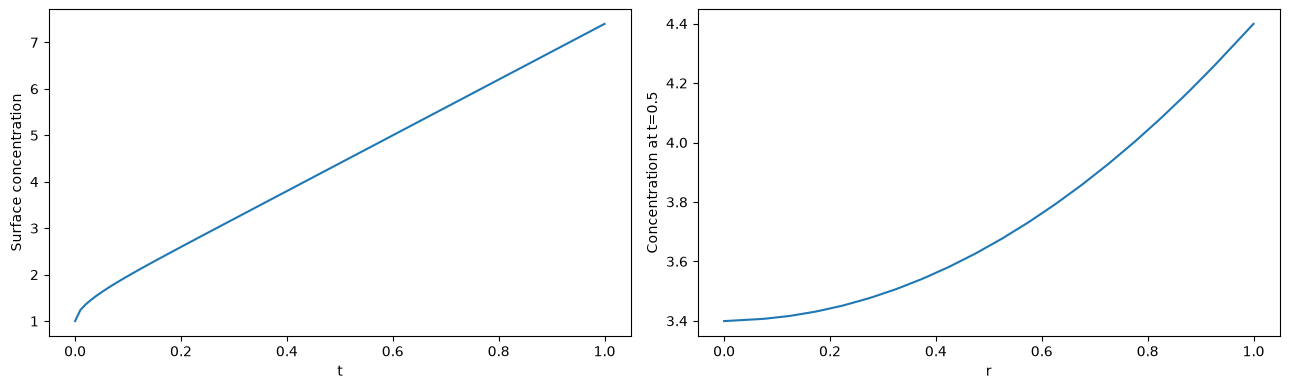

In [10]:
# solve
solver = pybamm.ScipySolver()
t = np.linspace(0, 1, 100)
solution = solver.solve(model, t)

# post-process, so that the solution can be called at any time t or space r
# (using interpolation)
c = solution["Concentration"]

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(solution.t, c(solution.t, r=1))
ax1.set_xlabel("t")
ax1.set_ylabel("Surface concentration")
r = np.linspace(0, 1, 100)
ax2.plot(r, c(t=0.5, r=r))
ax2.set_xlabel("r")
ax2.set_ylabel("Concentration at t=0.5")
plt.tight_layout()
plt.show()